# Part 3: Real-time Violation Analytics & Visualization (2.2.1, 2.2.2)

This notebook provides comprehensive real-time visualization and analysis of traffic violations captured by the streaming pipeline. It connects to MongoDB to retrieve processed violation data and creates three interactive dashboards:

1. **Real-time Time-Series Chart** — Dual-axis visualization showing average violation speeds over time with percentile references and violation counts
2. **Daily Top 10 Violators Report** — Interactive date-based analysis of the most frequent violators with detailed statistics
3. **Geographic Map Overlay** — Interactive folium map displaying violations by location with heatmaps, camera markers, route severity indicators, and summary statistics

The visualization layer serves as the reporting interface for traffic enforcement authorities, enabling real-time monitoring and analytical investigation of violations.

In [1]:
!pip install folium

In [2]:
from datetime import datetime, timedelta
import time
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymongo import MongoClient
import folium
from folium.plugins import HeatMap
from folium.features import DivIcon
from pymongo import MongoClient
from collections import defaultdict
import config

In [3]:
mongo_client = None

def get_mongo():
    """
    Return the MongoDB database instance.
    """
    global mongo_client

    if mongo_client is None:
        mongo_client = MongoClient(config.MONGO_URI)

    return mongo_client[config.DB_NAME]

# Code Configuration For The 3 Charts

## Real-time Time-Series Visualization

The real-time chart provides continuous monitoring of violation trends over a 4-hour sliding window, updating every 10 minutes.

**Visualization Design:**

* **Dual-axis display**: Left axis shows average violation speed (steelblue), right axis shows violation count (crimson)
* **Speed metrics**: Plots average speed with min/max scatter markers for context
* **Percentile lines**: P25, P50, P75, P90, P95 reference lines enable identification of violation severity trends
* **Annotations**: Red arrow marks maximum speed, orange arrow marks minimum speed for quick identification of extremes
* **Anomaly detection**: Spike and drop detection automatically highlights sudden changes in speed (15% threshold) with red stars and violation count anomalies with gold stars for rapid identification of abnormal patterns
* **Severity shading**: Background colored bands indicate violation severity—red for high (≥10 violations), orange for moderate (≥7 violations), and green for normal—providing visual context for traffic conditions
* **Combined legend**: Single legend combining both axes plus anomaly indicators with 7-column layout for professional presentation

**Data Pipeline:**

The chart polls MongoDB every 0.5 seconds using:
* Time window filtering (INSTANTANEOUS violations only)
* Aggregation pipeline for min/max/avg/count computations
* Rolling 4-hour window with 10-minute interval buckets
* Automatic spike/drop detection using percentage change analysis (15% threshold for speed, 20% for violation count)
* Severity-based background shading for visual pattern recognition
* Automatic state management (sliding window trim as new data arrives)

In [4]:
%matplotlib notebook

# Configure parameters here
POLL_INTERVAL = 0.5 # seconds
INTERVAL_SIZE = 10  # minutes
WINDOW_SIZE = timedelta(hours=4)

# Fixed values
CAMERAS = [1, 2, 3]
UPPER_BOUND = datetime(2024, 1, 1, 8, 0, 0)
LOWER_BOUND = UPPER_BOUND - timedelta(minutes=INTERVAL_SIZE)

average_A = None
average_B = None
average_C = None
average_all = None


def init_plots():
    """
    Initialise the real-time matplotlib figure.

    Returns
    -------
    tuple
        Figure and axis objects for real-time plotting.
    """
    try:
        plt.ion()

        fig = plt.figure(figsize=(13, 10))
        fig.subplots_adjust(hspace=0.8)

        ax1 = fig.add_subplot(111)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Speed (km/h)')

        fig.suptitle('Real-time average violation tracking')

        # Display interactive plot
        fig.show()
        fig.canvas.draw()

        return fig, ax1

    except Exception as ex:
        print(str(ex))


def annotate_max(x, y, ax=None):
    """
    Annotate the maximum value on a plot.

    Parameters
    ----------
    x : list
        X-axis values.
    y : list
        Y-axis values.
    ax : matplotlib.axes.Axes, optional
        Target axis object.
    """
    ymax = max(y)
    xpos = y.index(ymax)

    xmax = x[xpos]
    text = f"Max: {ymax:.2f}"

    if not ax:
        ax = plt.gca()

    ax.annotate(
        text,
        xy=(xmax, ymax),
        xytext=(xmax, ymax + 5),
        arrowprops=dict(facecolor='red', shrink=0.05),
    )


def annotate_min(x, y, ax=None):
    """
    Annotate the minimum value on a plot.

    Parameters
    ----------
    x : list
        X-axis values.
    y : list
        Y-axis values.
    ax : matplotlib.axes.Axes, optional
        Target axis object.
    """
    ymin = min(y)
    xpos = y.index(ymin)

    xmin = x[xpos]
    text = f"Min: {ymin:.2f}"

    if not ax:
        ax = plt.gca()

    ax.annotate(
        text,
        xy=(xmin, ymin),
        xytext=(xmin, ymin + 5),
        arrowprops=dict(facecolor='orange', shrink=0.05),
    )


def detect_spikes_and_drops(values, threshold_percent=15):
    """
    Detect sudden spikes and drops in speed or violation count.

    Parameters
    ----------
    values : list
        Time series values to analyze.
    threshold_percent : float
        Percentage change to consider as spike/drop (default 15%).

    Returns
    -------
    list
        Indices where spikes/drops occur.
    """
    if len(values) < 2:
        return []

    anomalies = []
    for i in range(1, len(values)):
        if values[i-1] != 0:
            percent_change = abs((values[i] - values[i-1]) / values[i-1] * 100)
            if percent_change > threshold_percent:
                anomalies.append(i)
    return anomalies


def add_severity_shading(ax, t_vals, v_counts, high_threshold=10):
    """
    Add colored background shading to indicate severity levels.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axis object.
    t_vals : list
        Time values.
    v_counts : list
        Violation counts.
    high_threshold : int
        Threshold above which violations are considered "high".
    """
    if len(t_vals) < 2:
        return

    for i in range(len(t_vals) - 1):
        # Define severity color based on violation count
        if v_counts[i] >= high_threshold:
            color = 'red'
            alpha = 0.08
        elif v_counts[i] >= high_threshold * 0.7:
            color = 'orange'
            alpha = 0.06
        else:
            color = 'green'
            alpha = 0.04

        ax.axvspan(t_vals[i], t_vals[i+1], alpha=alpha, color=color)


all_speed_readings = []


def consume_messages(fig, ax1):
    """
    Continuously poll MongoDB and update the real-time violation plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Matplotlib figure object.
    ax1 : matplotlib.axes.Axes
        Primary axis used for speed plotting.
    """
    global LOWER_BOUND, UPPER_BOUND, POLL_INTERVAL

    t1, avg_all, min_all, max_all, violation_counts = [], [], [], [], []
    all_speed_readings = []

    db = get_mongo()
    
    # Create secondary y-axis for violation counts
    ax2 = ax1.twinx()

    while True:

        # -------------------------
        # MATCH WINDOW (unwound data)
        # -------------------------
        match_stage = {
            '$match': {
                'violations.timestamp_start': {
                    '$gt': LOWER_BOUND,
                    '$lte': UPPER_BOUND
                },
                # Recommended: avoid mixing avg + instantaneous
                'violations.violation_type': 'INSTANTANEOUS'
            }
        }

        # -------------------------
        # AGGREGATE STATS
        # -------------------------
        average_all = list(db.violations.aggregate([
            {'$unwind': '$violations'},
            match_stage,
            {
                '$group': {
                    '_id': None,
                    'avg': {'$avg': '$violations.speed_reading'},
                    'min': {'$min': '$violations.speed_reading'},
                    'max': {'$max': '$violations.speed_reading'},
                    'count': {'$sum': 1}
                }
            }
        ]))

        # -------------------------
        # RAW POINTS FOR PLOTTING
        # -------------------------
        speed_points = list(db.violations.aggregate([
            {'$unwind': '$violations'},
            match_stage,
            {
                '$project': {
                    '_id': 0,
                    'speed_reading': '$violations.speed_reading',
                    'timestamp': '$violations.timestamp_start'
                }
            }
        ]))

        current_speeds = [d['speed_reading'] for d in speed_points]

        # Extract aggregate values safely
        if average_all:
            avg_value = average_all[0]['avg']
            min_value = average_all[0]['min']
            max_value = average_all[0]['max']
            count_value = average_all[0]['count']
        else:
            avg_value = min_value = max_value = count_value = 0

        # -------------------------
        # PERCENTILES
        # -------------------------
        all_speed_readings.extend(current_speeds)

        if len(all_speed_readings) > 0:
            p25 = np.percentile(all_speed_readings, 25)
            p50 = np.percentile(all_speed_readings, 50)
            p75 = np.percentile(all_speed_readings, 75)
            p90 = np.percentile(all_speed_readings, 90)
            p95 = np.percentile(all_speed_readings, 95)

        # -------------------------
        # STORE TIME SERIES
        # -------------------------
        avg_all.append(avg_value)
        min_all.append(min_value)
        max_all.append(max_value)
        violation_counts.append(count_value)
        t1.append(UPPER_BOUND)

        # -------------------------
        # PLOT
        # -------------------------
        if len(avg_all) > 10:

            ax1.clear()
            ax2.clear()

            # Detect spikes and drops in speed and violation counts
            speed_anomalies = detect_spikes_and_drops(avg_all, threshold_percent=15)
            violation_anomalies = detect_spikes_and_drops(violation_counts, threshold_percent=20)

            # Add severity shading background
            add_severity_shading(ax1, t1, violation_counts, high_threshold=10)

            # Plot speed data on left axis
            line1 = ax1.plot(t1, avg_all, marker='o', label="Average Speed", color='steelblue', linewidth=2)

            # Highlight anomalies on speed line
            for idx in speed_anomalies:
                if idx < len(t1) and idx < len(avg_all):
                    ax1.scatter([t1[idx]], [avg_all[idx]], s=150, marker='*', color='red', zorder=5, edgecolors='darkred', linewidth=1)

            # percentile reference lines
            ax1.axhline(p25, linestyle='--', label='P25', color="red", alpha=0.6)
            ax1.axhline(p50, linestyle='--', label='P50', color="orange", alpha=0.6)
            ax1.axhline(p75, linestyle='--', label='P75', color="green", alpha=0.6)
            ax1.axhline(p90, linestyle='--', label='P90', color="blue", alpha=0.6)
            ax1.axhline(p95, linestyle='--', label='P95', color="purple", alpha=0.6)

            ax1.scatter(t1, min_all, s=40, marker='v', label='Window Min', color='steelblue')
            ax1.scatter(t1, max_all, s=40, marker='^', label='Window Max', color='steelblue')

            annotate_max(t1, avg_all, ax1)
            annotate_min(t1, avg_all, ax1)

            ax1.set_xlabel("Time")
            ax1.set_ylabel("Speed (km/h)", color='steelblue')
            ax1.tick_params(axis='y', labelcolor='steelblue')

            # Plot violation count on right axis
            line2 = ax2.plot(t1, violation_counts, marker='s', label="Violation Count", color='crimson', linewidth=2)

            # Highlight anomalies on violation count
            for idx in violation_anomalies:
                if idx < len(t1) and idx < len(violation_counts):
                    ax2.scatter([t1[idx]], [violation_counts[idx]], s=150, marker='*', color='gold', zorder=5, edgecolors='orange', linewidth=1)

            ax2.set_ylabel("Violation Count", color='crimson')
            ax2.tick_params(axis='y', labelcolor='crimson')

            ax1.xaxis.set_major_formatter(
                mdates.DateFormatter('%Y-%m-%d %H:%M')
            )

            ax1.xaxis.set_major_locator(
                mdates.MinuteLocator(interval=10)
            )

            ax1.set_xlim(min(t1), max(t1))

            fig.autofmt_xdate()

            # Combine legends from both axes
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            
            # Add custom legend entries for anomalies
            from matplotlib.lines import Line2D
            custom_lines = [
                Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12, markeredgecolor='darkred'),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=12, markeredgecolor='orange')
            ]
            custom_labels = ['Speed Spike/Drop', 'Violation Spike/Drop']
            
            ax1.legend(
                lines1 + lines2 + custom_lines,
                labels1 + labels2 + custom_labels,
                loc='upper center',
                bbox_to_anchor=(0.5, 1.12),
                ncol=7,
                fontsize=9
            )

            fig.canvas.draw()
            plt.pause(0.01)
            fig.canvas.flush_events()

            # sliding window trim
            t1.pop(0)
            avg_all.pop(0)
            min_all.pop(0)
            max_all.pop(0)
            violation_counts.pop(0)

        # -------------------------
        # MOVE TIME WINDOW
        # -------------------------
        LOWER_BOUND = UPPER_BOUND
        UPPER_BOUND += timedelta(minutes=INTERVAL_SIZE)

        time.sleep(POLL_INTERVAL)

# if __name__ == '__main__':
#     fig, ax1 = init_plots()
#     consume_messages(fig, ax1)


### Top 10 Daily Violations

## Daily Top Violators Report with Statistics

The daily analysis provides a historical perspective on violation patterns, enabling identification of repeat offenders and trend analysis.

**Interactive Features:**

* **Date dropdown selector**: Choose any date from available data to update the report dynamically
* **Horizontal bar chart**: Top 10 vehicle owners ranked by total violation count with value labels
* **Color-coded statistics table**: Comprehensive daily metrics displayed below the chart

**Statistics Displayed:**

The report aggregates violation data by type and calculates:
* **Total Violations**: Sum of all violations for the selected date
* **Instantaneous Violations**: Count of speeding violations at individual cameras
* **Speed Violations**: Count of average-speed violations between camera pairs
* **Avg Instantaneous Speed**: Mean speed from instantaneous violations (km/h)
* **Avg Speed Violation Speed**: Mean speed from average-speed violations (km/h)

**MongoDB Aggregation Pipeline:**

The system performs complex aggregation including:
1. Date filtering to isolate daily records
2. Vehicle array size projection to count violations
3. Lookup join with vehicles collection to retrieve owner information
4. Grouping and sorting to identify top 10 violators
5. Secondary aggregation by violation type for statistics calculation

In [ ]:
%matplotlib notebook

import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display, HTML
import pandas as pd


def get_top_violators(day):
    """
    Retrieve the top 10 vehicle owners with the most violations.

    Parameters
    ----------
    day : str
        Selected date in ISO format.

    Returns
    -------
    list
        Aggregated top violator records.
    """
    db = get_mongo()

    pipeline = [

        # Filter by selected date
        {
            '$match': {
                'date': day
            }
        },

        # Count violations per document
        {
            '$project': {
                'car_plate': 1,
                'violation_count': {
                    '$size': '$violations'
                }
            }
        },

        # Join with vehicle owner information
        {
            '$lookup': {
                'from': 'vehicles',
                'localField': 'car_plate',
                'foreignField': 'car_plate',
                'as': 'vehicle_info'
            }
        },

        # Flatten joined vehicle array
        {
            '$unwind': '$vehicle_info'
        },

        # Group by owner name
        {
            '$group': {
                '_id': {
                    'owner_name' : '$vehicle_info.owner_name',
                    'owner_addr' : '$vehicle_info.owner_addr'
                },
                'total_violations': {
                    '$sum': '$violation_count'
                }
            }
        },

        # Sort descending
        {
            '$sort': {
                'total_violations': -1
            }
        },

        # Keep top 10 only
        {
            '$limit': 10
        }

    ]

    return list(db.violations.aggregate(pipeline))


def get_daily_statistics(day):
    """
    Retrieve daily violation statistics for a selected date.

    Parameters
    ----------
    day : str
        Selected date in ISO format.

    Returns
    -------
    list
        Aggregated daily violation statistics.
    """
    db = get_mongo()

    pipeline = [
        # Filter by selected date
        {
            '$match': {
                'date': day
            }
        },

        # Unwind violations array
        {
            '$unwind': '$violations'
        },

        # Group by violation type and aggregate stats
        {
            '$group': {
                '_id': '$violations.violation_type',
                'count': {'$sum': 1},
                'avg_speed': {'$avg': '$violations.speed_reading'}
            }
        }
    ]

    return list(db.violations.aggregate(pipeline))


# Retrieve all available dates
db = get_mongo()

available_dates = sorted(
    db.violations.distinct('date')
)

if len(available_dates) == 0:
    raise Exception("No dates found in violations collection")


def update_chart(selected_date):
    """
    Update the violation chart and daily statistics display.

    Parameters
    ----------
    selected_date : str
        Selected date in ISO format.
    """
    ax.clear()

    top_violators = get_top_violators(selected_date)

    # Handle empty result
    if len(top_violators) == 0:

        ax.set_title(
            f"No data found for {selected_date}"
        )

        fig.canvas.draw_idle()

        return

    # Extract plotting data
    owners = [
        d['_id']['owner_name']
        for d in top_violators
    ]

    counts = [
        d['total_violations']
        for d in top_violators
    ]

    # Reverse so largest appears at the top
    owners = owners[::-1]
    counts = counts[::-1]

    # Horizontal bar chart
    bars = ax.barh(
        owners,
        counts,
        color='steelblue'
    )

    ax.set_title(
        f"Top 10 by Violations ({selected_date})",
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel("Violation Count")
    ax.set_ylabel("Owner Name")

    # Add padding space for value labels
    ax.set_xlim(0, max(counts) * 1.15)

    # Add value labels
    for bar, count in zip(bars, counts):

        width = bar.get_width()

        ax.text(
            width + 0.2,
            bar.get_y() + bar.get_height() / 2,
            str(count),
            va='center'
        )

    plt.tight_layout()

    fig.canvas.draw_idle()

    # ============================
    # GET AND DISPLAY STATISTICS
    # ============================
    daily_stats = get_daily_statistics(selected_date)

    total_violations = 0
    instantaneous_count = 0
    speed_count = 0
    instantaneous_speed = 0
    speed_violation_speed = 0

    for stat in daily_stats:
        violation_type = stat['_id']
        count = stat['count']
        avg_speed = stat['avg_speed']

        total_violations += count

        if violation_type == 'INSTANTANEOUS':
            instantaneous_count = count
            instantaneous_speed = avg_speed
        elif violation_type == 'AVERAGE':
            speed_count = count
            speed_violation_speed = avg_speed

    # Create statistics display (AI used to improve aesthetics of the information box)
    stats_html = f"""
    <div style="
        background-color: #f8f9fa;
        border: 2px solid #3498db;
        border-radius: 8px;
        padding: 20px;
        margin-top: 15px;
        font-family: Arial, sans-serif;
    ">
        <h3 style="margin-top: 0; color: #2c3e50; text-align: center; border-bottom: 2px solid #3498db; padding-bottom: 10px;">
            📊 Daily Violation Statistics - {selected_date}
        </h3>
        
        <table style="width: 100%; margin-top: 15px; border-collapse: collapse;">
            <tr style="background-color: #e8f4f8;">
                <td style="padding: 10px; border: 1px solid #bdc3c7;"><b>Total Violations:</b></td>
                <td style="padding: 10px; border: 1px solid #bdc3c7; text-align: right; font-size: 16px; color: #2980b9;"><b>{total_violations}</b></td>
            </tr>
            <tr style="background-color: #fff5e6;">
                <td style="padding: 10px; border: 1px solid #bdc3c7;"><b>Instantaneous Violations:</b></td>
                <td style="padding: 10px; border: 1px solid #bdc3c7; text-align: right; font-size: 16px; color: #e74c3c;"><b>{instantaneous_count}</b></td>
            </tr>
            <tr style="background-color: #e8f8f5;">
                <td style="padding: 10px; border: 1px solid #bdc3c7;"><b>Speed Violations:</b></td>
                <td style="padding: 10px; border: 1px solid #bdc3c7; text-align: right; font-size: 16px; color: #27ae60;"><b>{speed_count}</b></td>
            </tr>
            <tr style="background-color: #f0e6ff;">
                <td style="padding: 10px; border: 1px solid #bdc3c7;"><b>Avg Instantaneous Speed:</b></td>
                <td style="padding: 10px; border: 1px solid #bdc3c7; text-align: right; font-size: 16px; color: #8e44ad;"><b>{instantaneous_speed:.2f} km/h</b></td>
            </tr>
            <tr style="background-color: #ffe6f0;">
                <td style="padding: 10px; border: 1px solid #bdc3c7;"><b>Avg Speed Violation Speed:</b></td>
                <td style="padding: 10px; border: 1px solid #bdc3c7; text-align: right; font-size: 16px; color: #c0392b;"><b>{speed_violation_speed:.2f} km/h</b></td>
            </tr>
        </table>
    </div>
    """

    stats_output.clear_output()
    with stats_output:
        display(HTML(stats_html))


def on_change(change):
    """
    Handle dropdown value changes and refresh the chart.

    Parameters
    ----------
    change : dict
        Widget state change event.
    """
    if change['type'] == 'change' and change['name'] == 'value':

        selected_date = change['new']

        update_chart(selected_date)

### Map View of Violations

## Geographic Map Visualization with Heatmaps & Analytics

The map layer provides spatial context for violation patterns, enabling geographic analysis and route-based enforcement strategy planning.

**Map Components:**

* **Heatmap layer**: Intensity visualization of instantaneous violations by camera location, using radius=40 and blur=30 for smooth density representation
* **Camera markers**: Blue markers with camera icons positioned at each enforcement point, showing aggregated statistics
* **Route polylines**: Color-coded connections between adjacent cameras indicating average-speed violation severity:
  - Red: > 130 km/h (dangerous speeding)
  - Orange: > 120 km/h (dangerous speeding)  
  - Yellow: > 110 km/h (dangerous speeding)
  - Green: <= 110 km/h (dangerous speeding)

**Overlay Statistics Panels (Fixed Position):**

* **Summary statistics** (top-right): Total violations, overall average speed, instantaneous violation count with average, and speed violation count with average
* **Tracking window** (bottom-right): Date-time range of displayed data for context

**Data Aggregation Pipeline:**

The map aggregates all violations by:
1. Unwinding violations array to expose individual records
2. Grouping by camera ID and violation type
3. Computing count and average speed per camera and type
4. Extracting min/max timestamps for temporal context

This enables comprehensive geographic analysis across all three enforcement cameras and the two monitored routes.

In [ ]:
# ============================================================
# DB + CAMERA CONFIG
# ============================================================

db = get_mongo()
collection = db["violations"]

camera_locations = {
    camera["camera_id"]: (
        f"Camera {chr(64 + camera['camera_id'])}",
        [camera["latitude"], camera["longitude"]]
    )
    for camera in db.cameras.find()
}

# ============================================================
# AGGREGATION PIPELINE
# ============================================================

pipeline = [
    {"$unwind": "$violations"},
    {
        "$group": {
            "_id": {
                "camera_id":      "$violations.camera_id_end",
                "violation_type": "$violations.violation_type"
            },
            "count":         {"$sum": 1},
            "avg_speed":     {"$avg": "$violations.speed_reading"},
            "min_timestamp": {"$min": "$violations.timestamp_start"},
            "max_timestamp": {"$max": "$violations.timestamp_start"}
        }
    }
]

results = list(collection.aggregate(pipeline))

# ============================================================
# PROCESS RESULTS
# ============================================================

instantaneous_counts     = defaultdict(int)
average_counts           = defaultdict(int)
instantaneous_avg_speeds = defaultdict(float)
average_avg_speeds       = defaultdict(float)
timestamps = []

for doc in results:
    camera_id      = doc["_id"]["camera_id"]
    violation_type = doc["_id"]["violation_type"]
    count          = doc["count"]
    avg_speed      = doc["avg_speed"]

    timestamps += [doc["min_timestamp"], doc["max_timestamp"]]

    if violation_type == "INSTANTANEOUS":
        instantaneous_counts[camera_id]     = count
        instantaneous_avg_speeds[camera_id] = avg_speed
    elif violation_type == "AVERAGE":
        average_counts[camera_id]     = count
        average_avg_speeds[camera_id] = avg_speed

if not timestamps:
    raise ValueError("No data found in violations collection")

min_time = min(timestamps)
max_time = max(timestamps)

# ============================================================
# SUMMARY STATS
# ============================================================

total_instant_violations  = sum(instantaneous_counts.values())
total_speed_violations    = sum(average_counts.values())
total_violations          = total_instant_violations + total_speed_violations

avg_instant_speed         = sum(instantaneous_avg_speeds.values()) / len(instantaneous_avg_speeds) if instantaneous_avg_speeds else 0
avg_speed_violation_speed = sum(average_avg_speeds.values()) / len(average_avg_speeds) if average_avg_speeds else 0
overall_avg_speed         = (avg_instant_speed + avg_speed_violation_speed) / 2 if (avg_instant_speed or avg_speed_violation_speed) else 0

# ============================================================
# MAP SETUP
# ============================================================

m = folium.Map(
    location=[2.162418757, 102.6524549],
    zoom_start=15,
    tiles="CartoDB positron"
)

# ============================================================
# HEATMAP
# ============================================================

heat_data = [
    [coord[0], coord[1], count]
    for camera_id, count in instantaneous_counts.items()
    for _, coord in [camera_locations[camera_id]]
]

HeatMap(heat_data, radius=40, blur=30).add_to(m)

# ============================================================
# CAMERA MARKERS
# ============================================================

for camera_id, (name, coord) in camera_locations.items():
    instant_count     = instantaneous_counts[camera_id]
    avg_count         = average_counts[camera_id]
    instant_avg_speed = instantaneous_avg_speeds[camera_id]
    avg_avg_speed     = average_avg_speeds[camera_id]

    popup_html = f"""
    <div style="width:300px;font-size:14px;font-family:sans-serif;">
        <h4 style="margin:0 0 8px;">{name}</h4>
        <b>Camera ID:</b> {camera_id}<br><br>
        <b>Instantaneous violations:</b> {instant_count}<br>
        <b>Avg instantaneous speed:</b> {instant_avg_speed:.2f} km/h<br><br>
        <b>Average-speed violations:</b> {avg_count}<br>
        <b>Avg route speed:</b> {avg_avg_speed:.2f} km/h
    </div>
    """

    folium.Marker(
        location=coord,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=name
    ).add_to(m)

# ============================================================
# ROUTE COLOR + POLYLINES
# ============================================================

def get_route_color(avg_speed):
    """
    Determine route colour based on average vehicle speed.

    Parameters
    ----------
    avg_speed : float
        Average vehicle speed in km/h.

    Returns
    -------
    str
        Colour representing the severity level.
    """
    if avg_speed > 130: return "red"
    if avg_speed > 120: return "orange"
    if avg_speed > 110: return "yellow"
    return "green"

route_mappings = {
    2: (1, 2),
    3: (2, 3)
}

for avg_camera_id, (start_cam, end_cam) in route_mappings.items():
    start_coord     = camera_locations[start_cam][1]
    end_coord       = camera_locations[end_cam][1]
    violation_count = average_counts[avg_camera_id]
    avg_speed       = average_avg_speeds[avg_camera_id]
    route_color     = get_route_color(avg_speed)

    popup_html = f"""
    <div style="width:300px;font-size:14px;font-family:sans-serif;">
        <h4 style="margin:0 0 8px;">Route: Camera {start_cam} → Camera {end_cam}</h4>
        <b>Average-speed violations:</b> {violation_count}<br>
        <b>Average speed:</b> {avg_speed:.2f} km/h<br>
        <b>Severity:</b> {route_color.upper()}
    </div>
    """

    folium.PolyLine(
        locations=[start_coord, end_coord],
        color=route_color,
        weight=6,
        opacity=0.8,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"Route {start_cam} → {end_cam}"
    ).add_to(m)

# ============================================================
# HTML OVERLAYS (injected as raw HTML to look nicer)
# ============================================================

overlay_html = f"""
<div style="
    position: fixed; top: 16px; right: 16px; z-index: 1000;
    font-family: sans-serif;
    background: rgba(255,255,255,0.93);
    border: 1px solid #ccc;
    border-radius: 10px;
    padding: 12px 16px;
    width: 340px;
    font-size: 13px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15);
">
    <div style="font-weight:600;font-size:14px;margin-bottom:10px;">&#128200; Violation Summary</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;">

        <div style="background:#f5f5f5;border-radius:7px;padding:8px 10px;">
            <div style="color:#888;font-size:11px;">Total violations</div>
            <div style="font-size:20px;font-weight:600;">{total_violations}</div>
        </div>

        <div style="background:#f5f5f5;border-radius:7px;padding:8px 10px;">
            <div style="color:#888;font-size:11px;">Overall avg speed</div>
            <div style="font-size:20px;font-weight:600;">{overall_avg_speed:.1f} <span style="font-size:12px;font-weight:400;">km/h</span></div>
        </div>

        <div style="background:#fff3f3;border-radius:7px;padding:8px 10px;">
            <div style="color:#c0392b;font-size:11px;">&#9889; Instantaneous violations</div>
            <div style="font-size:18px;font-weight:600;">{total_instant_violations}</div>
            <div style="font-size:11px;color:#888;">avg {avg_instant_speed:.1f} km/h</div>
        </div>

        <div style="background:#fff8f0;border-radius:7px;padding:8px 10px;">
            <div style="color:#e67e22;font-size:11px;">&#128739; Avg-speed violations</div>
            <div style="font-size:18px;font-weight:600;">{total_speed_violations}</div>
            <div style="font-size:11px;color:#888;">avg {avg_speed_violation_speed:.1f} km/h</div>
        </div>

    </div>
</div>

<div style="
    position: fixed; bottom: 32px; left: 16px; z-index: 1000;
    font-family: sans-serif;
    background: rgba(255,255,255,0.93);
    border: 1px solid #ccc;
    border-radius: 10px;
    padding: 12px 16px;
    font-size: 13px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15);
">
    <div style="font-weight:600;font-size:14px;margin-bottom:10px;">&#128246; Route Severity</div>
    <div style="display:flex;align-items:center;gap:10px;margin:6px 0;">
        <span style="display:inline-block;width:28px;height:5px;background:red;border-radius:3px;"></span>
        <span style="color:#555;">Critical &nbsp;&mdash;&nbsp; avg speed &gt; 130 km/h</span>
    </div>
    <div style="display:flex;align-items:center;gap:10px;margin:6px 0;">
        <span style="display:inline-block;width:28px;height:5px;background:orange;border-radius:3px;"></span>
        <span style="color:#555;">High &nbsp;&mdash;&nbsp; avg speed &gt; 120 km/h</span>
    </div>
    <div style="display:flex;align-items:center;gap:10px;margin:6px 0;">
        <span style="display:inline-block;width:28px;height:5px;background:#c9a800;border-radius:3px;"></span>
        <span style="color:#555;">Moderate &nbsp;&mdash;&nbsp; avg speed &gt; 110 km/h</span>
    </div>
    <div style="display:flex;align-items:center;gap:10px;margin:6px 0;">
        <span style="display:inline-block;width:28px;height:5px;background:green;border-radius:3px;"></span>
        <span style="color:#555;">Normal &nbsp;&mdash;&nbsp; avg speed &le; 110 km/h</span>
    </div>
</div>

<div style="
    position: fixed; bottom: 32px; right: 16px; z-index: 1000;
    font-family: sans-serif;
    font-size: 13px;
    color: white;
    background: rgba(0,0,0,0.72);
    padding: 10px 14px;
    border-radius: 8px;
    width: 300px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.2);
">
    <b>Tracking window</b><br>
    {min_time.strftime('%Y-%m-%d %H:%M:%S')}<br>
    &rarr; {max_time.strftime('%Y-%m-%d %H:%M:%S')}
</div>
"""

m.get_root().html.add_child(folium.Element(overlay_html))

# View Charts

## Execution Guide

The visualization notebook provides three independent, interactive dashboards. Execute the cells below to display each visualization:

**Real-time Chart (Cell below):**
* Displays a continuously updating 4-hour sliding window
* Updates every 0.5 seconds via MongoDB polling
* **Note**: Interrupt the kernel to stop the real-time update loop

**Daily Report (Cell below):**
* Renders immediately upon execution
* Interactive date dropdown allows filtering by any available date
* Statistics update dynamically when date changes
* No kernel interruption required

**Map Visualization (Cell below):**
* Renders immediately upon execution
* Fully interactive folium map with pan/zoom capabilities
* Overlay panels fixed in top-right and bottom-right corners
* Click markers or routes for detailed popup information

All three visualizations connect to the same MongoDB instance and operate on violation data processed by the streaming pipeline.

<IPython.core.display.Javascript object>


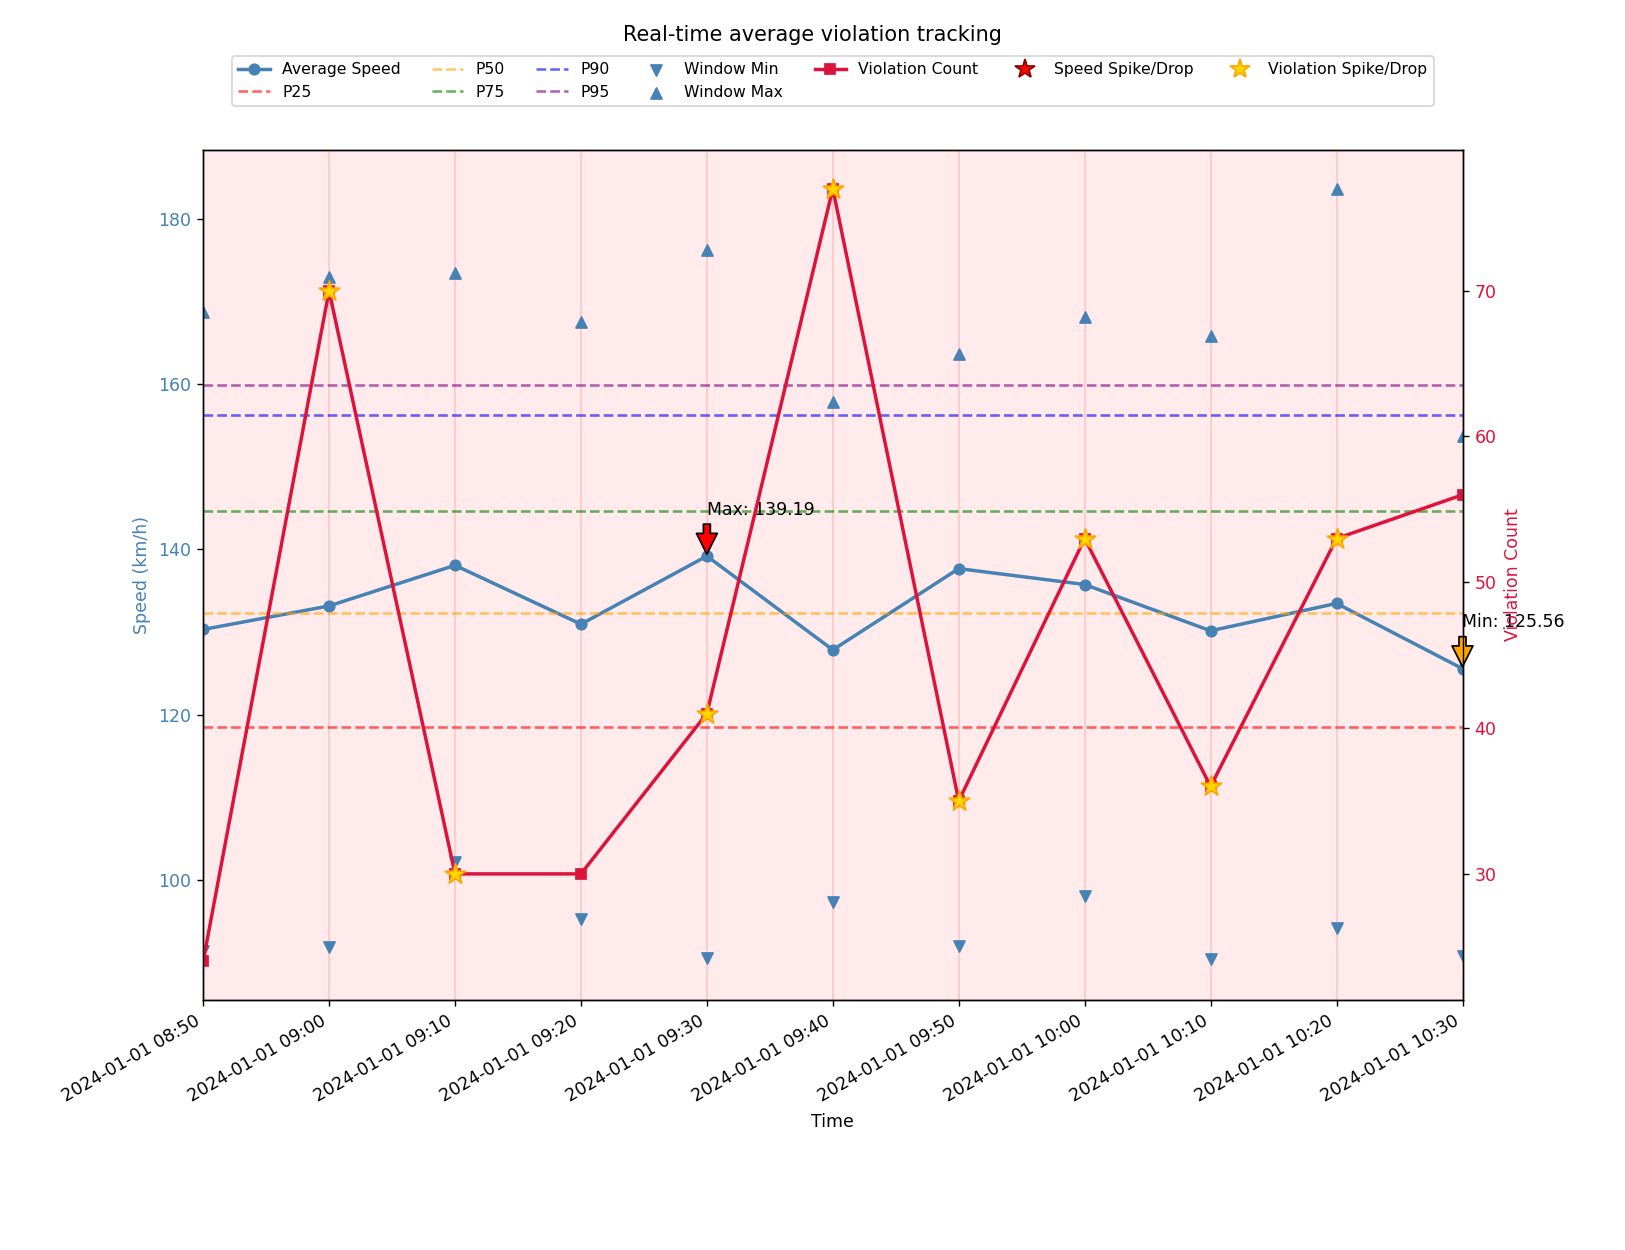

KeyboardInterrupt: 

In [5]:
# Plot of Average Violations Over Time
fig, ax1 = init_plots()
consume_messages(fig, ax1)

In [ ]:
# Plot of Top 10 Daily Violations
fig, ax = plt.subplots(figsize=(10, 6))

dropdown = widgets.Dropdown(
    options=available_dates,
    value=available_dates[0],
    description='Date:'
)

# Create output area for statistics
from ipywidgets import Output
stats_output = Output()

dropdown.observe(on_change)

display(dropdown)

# initial chart
update_chart(available_dates[0])

plt.show()

# Display statistics below chart
display(stats_output)

In [ ]:
# Map of Violations
m